In [6]:
import time
import pandas as pd
from zhinst.toolkit import Session
import numpy as np
import matplotlib.pyplot as plt

session = Session("localhost", hf2=True)
device = session.connect_device("DEV1004")

In [7]:

def get_noise_data(device,  TcSet = 1, numSamples = 100, demod = 3, tmeasure = np.inf):
    device.demods[demod].timeconstant(TcSet)
    TcReal = device.demods[demod].timeconstant()

    Tstart = time.time()
    data = pd.DataFrame()#device.demods[3].sample() )
    # concatenate the data with data
    for i in range(numSamples):
        time.sleep(10*TcSet)
        sample_data = pd.DataFrame(device.demods[demod].sample())
        sample_data['Time'] = time.time() - Tstart
        sample_data['TcSet'] = TcSet
        sample_data['TcReal'] = TcReal
        data = pd.concat([data, sample_data], axis=0)

        if float(sample_data['Time']) > tmeasure:
            break

    return data

In [8]:
data = get_noise_data(device,  TcSet = 0.001, numSamples = 3, demod = 3)
data

,timestamp,x,y,frequency,phase,dio,trigger,auxin0,auxin1,Time,TcSet,TcReal
0,212325618483200,-1.979452e-06,3.854835e-06,3347620.0,1.260760,526385151,3,-0.008545,-0.003967,0.035000,0.001,0.001002
0,212325625020416,2.440886e-06,-5.091335e-07,3347620.0,1.710319,526385151,3,-0.007935,-0.002747,0.068996,0.001,0.001002
0,212325633425408,-9.308262e-07,6.562779e-07,3347620.0,4.083519,526385151,3,-0.010071,-0.003052,0.109004,0.001,0.001002


In [9]:
results = dict()
tcs = [0.003, 0.01, 0.03, 0.1, 0.3, 1]
for tc in tcs:
    print(tc)
    data = get_noise_data(device,  TcSet = tc, numSamples = 100000000000000, demod = 3, tmeasure = 10)
    results[tc] = data




0.003
0.01
0.03
0.1
0.3
1


0.003 9.02413481018542e-07
0.01 4.968713322427726e-07
0.03 2.504633653130572e-07
0.1 2.291131741377962e-07
0.3 9.763016164890066e-08
1 nan


<AxesSubplot: xlabel='TcReal'>

<Figure size 640x480 with 0 Axes>

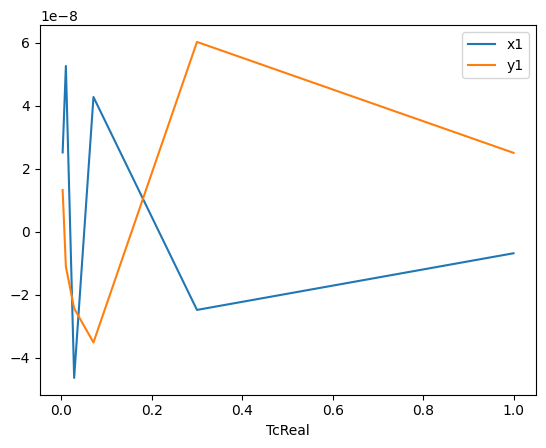

<Figure size 640x480 with 0 Axes>

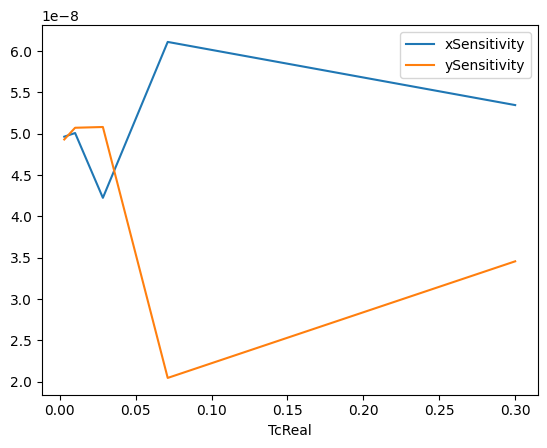

In [16]:
for tc , data in results.items():
    print(tc, data.x.std())

TcSet = [ data.TcSet.mean() for data in results.values()]
TcReal = [ data.TcReal.mean() for data in results.values()]
x1 = [ data.x.mean() for data in results.values()]
y1 = [ data.y.mean() for data in results.values()]
dx1 = [ data.x.std() for data in results.values()]
dy1 = [ data.y.std() for data in results.values()]

df = pd.DataFrame({'TcSet': TcSet, 'TcReal': TcReal, 'x1': x1, 'y1': y1, 'dx1': dx1, 'dy1': dy1})
df["xSensitivity"] = df.dx1 * np.sqrt(df.TcReal)
df["ySensitivity"] = df.dy1 * np.sqrt(df.TcReal)

plt.figure()
df.plot(x='TcReal', y=['x1','y1'])
# df.plot(x='TcReal', y='y1')

plt.figure()
df.plot(x='TcReal', y=['xSensitivity','ySensitivity'])
